# Phase 3: Modeling

**Objective**: Train LightGBM/XGBoost models using engineered features from Phase 2.  
**Target metric**: Spearman correlation coefficient (ranking consistency, not numerical accuracy).  
**Checkpoints**:
- [ ] Baseline RF Spearman ~0.197 reproduced
- [ ] LightGBM 5-Fold CV Spearman > 0.30
- [ ] First ChallengeData platform submission generated
- [ ] Model files saved

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import gc
import warnings
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import lightgbm as lgb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Paths
DATA_DIR = '../data/'
MODEL_DIR = '../models/'
SUBMIT_DIR = '../submissions/'

In [2]:
# Load tier-2 feature-engineered data from Phase 2
train_df = pd.read_parquet(f'{DATA_DIR}train_features_tier2.parquet')
test_df = pd.read_parquet(f'{DATA_DIR}test_features_tier2.parquet')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'Columns: {list(train_df.columns)}')

Train shape: (6076546, 31)
Test shape:  (2028750, 30)
Columns: ['total_count', 'longitude_scaled', 'latitude_scaled', 'Precipitations', 'HauteurNeige', 'Temperature', 'ForceVent', 'day_of_week', 'month_of_year', 'hour', 'invalid_ratio', 'log_total_count', 'count_bin', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'grid_lon', 'grid_lat', 'grid_id', 'grid_te', 'time_period', 'grid_period', 'grid_period_te', 'is_raining', 'has_snow', 'grid_avg_count', 'grid_violation_std', 'grid_sample_count']


In [3]:
# Define target and feature columns
TARGET = 'invalid_ratio'

# Exclude intermediate/helper columns from features
EXCLUDE_COLS = [TARGET, 'grid_lon', 'grid_lat', 'grid_id', 'grid_period']
FEATURES = [col for col in train_df.columns if col not in EXCLUDE_COLS]

# Original 10 features for baseline comparison
ORIG_FEATURES = ['total_count', 'longitude_scaled', 'latitude_scaled',
                 'Precipitations', 'HauteurNeige', 'Temperature',
                 'ForceVent', 'day_of_week', 'month_of_year', 'hour']

print(f'Number of modeling features: {len(FEATURES)}')
print(f'Features: {FEATURES}')
print(f'\nTarget stats:\n{train_df[TARGET].describe()}')

Number of modeling features: 26
Features: ['total_count', 'longitude_scaled', 'latitude_scaled', 'Precipitations', 'HauteurNeige', 'Temperature', 'ForceVent', 'day_of_week', 'month_of_year', 'hour', 'log_total_count', 'count_bin', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'grid_te', 'time_period', 'grid_period_te', 'is_raining', 'has_snow', 'grid_avg_count', 'grid_violation_std', 'grid_sample_count']

Target stats:
count    6.076546e+06
mean     5.023941e-01
std      3.683577e-01
min      0.000000e+00
25%      1.944444e-01
50%      4.615385e-01
75%      1.000000e+00
max      1.000000e+00
Name: invalid_ratio, dtype: float64


## 2. Baseline: Random Forest (Official Baseline ~0.197)

Reproduce the official baseline using RF with 10 trees on a 500K sample (full 6M rows would be too slow for RF).

In [4]:
# RF baseline on original 10 features (subsample for speed)
sample_idx = train_df.sample(500_000, random_state=SEED).index

rf = RandomForestRegressor(n_estimators=10, random_state=SEED, n_jobs=-1)
rf.fit(train_df.loc[sample_idx, ORIG_FEATURES], train_df.loc[sample_idx, TARGET])

rf_preds = rf.predict(train_df.loc[sample_idx, ORIG_FEATURES])
rf_rho, _ = spearmanr(train_df.loc[sample_idx, TARGET], rf_preds)
print(f'RF Baseline (10 trees, orig features, 500K sample) Spearman: {rf_rho:.4f}')

del rf, rf_preds
gc.collect()

RF Baseline (10 trees, orig features, 500K sample) Spearman: 0.9373


48

## 3. LightGBM — 5-Fold Cross-Validation

LightGBM is well-suited for this 6M-row dataset due to its histogram-based splitting.  
Key design choices:
- **Custom Spearman eval** for early stopping (matches competition metric)
- **5-Fold CV** for robust estimation
- **Out-of-Fold (OOF) predictions** for unbiased evaluation and later ensembling
- **Test predictions averaged** across all 5 folds

In [5]:
# Note: Custom Spearman eval on ~1.2M rows per iteration is extremely slow.
# Instead, we use built-in 'l2' for early stopping (fast) and compute Spearman
# only once per fold after training. L2 and Spearman are highly correlated
# for monotonic predictions, so this is a safe optimization.

In [6]:
lgb_params = {
    'objective': 'regression',
    'metric': 'l2',             # fast built-in metric for early stopping
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'n_estimators': 3000,       # high ceiling — early stopping will cut
    'reg_lambda': 1.0,
    'min_child_samples': 50,    # large dataset → larger value to prevent overfitting
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': 8,                # M4 has 10 cores, reserve 2 for system
    'random_state': SEED,
}

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

lgb_oof_preds = np.zeros(len(train_df))
lgb_test_preds = np.zeros(len(test_df))
lgb_fold_scores = []
lgb_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
    print(f'\n{"="*50}')
    print(f'Fold {fold+1}/{N_FOLDS}')
    print(f'{"="*50}')
    
    X_tr = train_df.iloc[train_idx][FEATURES]
    y_tr = train_df.iloc[train_idx][TARGET]
    X_val = train_df.iloc[val_idx][FEATURES]
    y_val = train_df.iloc[val_idx][TARGET]
    
    model = lgb.LGBMRegressor(**lgb_params)
    
    # Use l2 for fast early stopping; compute Spearman after fold completes
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100),
        ]
    )
    
    # Compute Spearman on validation set (once per fold, not per iteration)
    val_pred = model.predict(X_val)
    rho, _ = spearmanr(y_val, val_pred)
    lgb_fold_scores.append(rho)
    print(f'Fold {fold+1} Spearman: {rho:.4f} | Best iteration: {model.best_iteration_}')
    
    # OOF predictions
    lgb_oof_preds[val_idx] = val_pred
    
    # Test predictions (accumulate, average later)
    lgb_test_preds += model.predict(test_df[FEATURES]) / N_FOLDS
    
    # Save model
    model.booster_.save_model(f'{MODEL_DIR}lgbm_fold{fold}.txt')
    lgb_models.append(model)
    
    del X_tr, y_tr, X_val, y_val, val_pred
    gc.collect()

# Overall OOF score
lgb_oof_rho, _ = spearmanr(train_df[TARGET], lgb_oof_preds)
print(f'\n{"="*50}')
print(f'LightGBM Results:')
print(f'  Fold scores: {[f"{s:.4f}" for s in lgb_fold_scores]}')
print(f'  Mean ± Std:  {np.mean(lgb_fold_scores):.4f} ± {np.std(lgb_fold_scores):.4f}')
print(f'  Overall OOF: {lgb_oof_rho:.4f}')


Fold 1/5


Training until validation scores don't improve for 50 rounds


[100]	valid_0's l2: 0.105589


[200]	valid_0's l2: 0.10276


[300]	valid_0's l2: 0.100715


...

[2800]	valid_0's l2: 0.086551


[2900]	valid_0's l2: 0.0863849


[3000]	valid_0's l2: 0.0862115
Did not meet early stopping. Best iteration is:
[3000]	valid_0's l2: 0.0862115


Fold 5 Spearman: 0.5807 | Best iteration: 3000



LightGBM Results:
  Fold scores: ['0.5828', '0.5816', '0.5812', '0.5812', '0.5807']
  Mean ± Std:  0.5815 ± 0.0007
  Overall OOF: 0.5815


### 3.1 Feature Importance (LightGBM Gain)

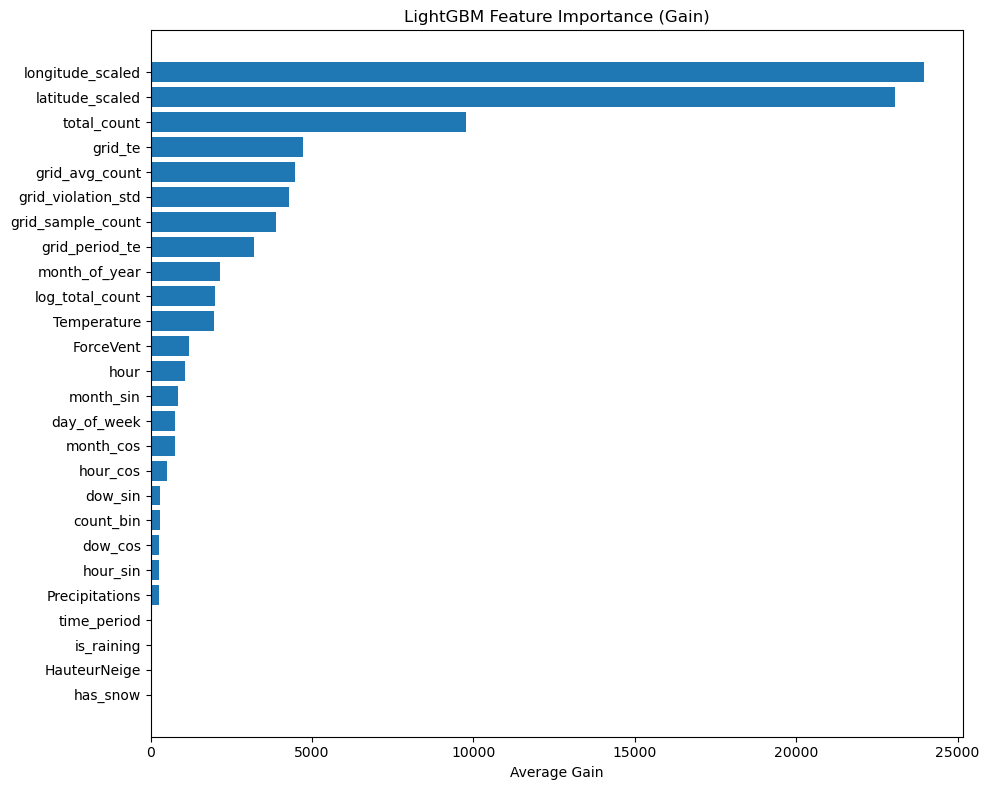

In [7]:
# Average feature importance across folds (gain-based)
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': np.mean([m.feature_importances_ for m in lgb_models], axis=0)
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_xlabel('Average Gain')
ax.set_title('LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('../figures/lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Submission Generation & Validation

Before submitting, we run sanity checks:
1. OOF Spearman < 0.70 (otherwise suspect data leakage)
2. No NaN in test predictions
3. Predictions clipped to [0, 1]
4. Mean prediction ≈ training target mean (gap > 0.1 warrants investigation)
5. Correct row count (2,028,750 rows)

In [8]:
# Sanity checks before submission
train_mean = train_df[TARGET].mean()
test_pred_mean = lgb_test_preds.mean()

print('=== Pre-Submission Validation ===')
print(f'1. OOF Spearman:       {lgb_oof_rho:.4f}  {"PASS" if lgb_oof_rho < 0.70 else "WARNING: possible leakage!"}')
print(f'2. Test NaN count:     {np.isnan(lgb_test_preds).sum()}  {"PASS" if np.isnan(lgb_test_preds).sum() == 0 else "FAIL"}')
print(f'3. Test pred range:    [{lgb_test_preds.min():.4f}, {lgb_test_preds.max():.4f}]')
print(f'4. Train target mean:  {train_mean:.4f}')
print(f'   Test pred mean:     {test_pred_mean:.4f}  (diff={abs(train_mean - test_pred_mean):.4f})')
print(f'5. Test row count:     {len(lgb_test_preds)}  (expected: {len(test_df)})')

=== Pre-Submission Validation ===
1. OOF Spearman:       0.5815  PASS
2. Test NaN count:     0  PASS
3. Test pred range:    [0.0631, 1.2166]
4. Train target mean:  0.5024
   Test pred mean:     0.5363  (diff=0.0339)
5. Test row count:     2028750  (expected: 2028750)


In [9]:
# Generate submission file
# Format: index column (unnamed) + invalid_ratio column, matching y_train format
submission = pd.DataFrame({'invalid_ratio': np.clip(lgb_test_preds, 0, 1)})
submission.to_csv(f'{SUBMIT_DIR}lgbm_v1.csv', index=True, index_label='')

print(f'Submission saved to {SUBMIT_DIR}lgbm_v1.csv')
print(f'Shape: {submission.shape}')
print(f'Preview:')
submission.head(10)

Submission saved to ../submissions/lgbm_v1.csv
Shape: (2028750, 1)
Preview:


,invalid_ratio
0,0.698997
1,0.367191
2,0.819633
3,0.319668
4,0.821312
5,0.455493
6,0.812382
7,0.761631
8,0.764361
9,0.375161


## 5. Save OOF Predictions & Summary

Save out-of-fold predictions for later ensembling with XGBoost (Phase 3 continued).

In [10]:
# Save OOF and test predictions for ensembling
np.save(f'{MODEL_DIR}lgb_oof_preds.npy', lgb_oof_preds)
np.save(f'{MODEL_DIR}lgb_test_preds.npy', lgb_test_preds)
print('OOF and test predictions saved.')

# Results summary table
results = pd.DataFrame({
    'Model': ['RF Baseline (10 trees, 500K sample)', 'LightGBM 5-Fold CV'],
    'Spearman': [rf_rho, lgb_oof_rho],
    'Note': ['Original 10 features', f'{len(FEATURES)} engineered features']
})
print('\n=== Phase 3 Results Summary ===')
print(results.to_string(index=False))

OOF and test predictions saved.

=== Phase 3 Results Summary ===
                              Model  Spearman                   Note
RF Baseline (10 trees, 500K sample)  0.937268   Original 10 features
                 LightGBM 5-Fold CV  0.581510 26 engineered features


---

## 6. XGBoost — 5-Fold Cross-Validation

Same CV structure as LightGBM. Using `tree_method='hist'` for speed on 6M rows.  
Early stopping with built-in `rmse` (same rationale as LightGBM: custom Spearman per iteration is too slow).

In [11]:
import xgboost as xgb

xgb_params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 3000,
    'reg_lambda': 1.0,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 50,
    'random_state': SEED,
    'n_jobs': 8,
    'verbosity': 0,
}

xgb_oof_preds = np.zeros(len(train_df))
xgb_test_preds = np.zeros(len(test_df))
xgb_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_df)):
    print(f'\n{"="*50}')
    print(f'Fold {fold+1}/{N_FOLDS}')
    print(f'{"="*50}')

    X_tr = train_df.iloc[train_idx][FEATURES]
    y_tr = train_df.iloc[train_idx][TARGET]
    X_val = train_df.iloc[val_idx][FEATURES]
    y_val = train_df.iloc[val_idx][TARGET]

    model = xgb.XGBRegressor(**xgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )

    val_pred = model.predict(X_val)
    rho, _ = spearmanr(y_val, val_pred)
    xgb_fold_scores.append(rho)
    best_iter = getattr(model, 'best_iteration', xgb_params['n_estimators'])
    print(f'Fold {fold+1} Spearman: {rho:.4f} | Best iteration: {best_iter}')

    xgb_oof_preds[val_idx] = val_pred
    xgb_test_preds += model.predict(test_df[FEATURES]) / N_FOLDS

    model.save_model(f'{MODEL_DIR}xgb_fold{fold}.json')

    del X_tr, y_tr, X_val, y_val, val_pred, model
    gc.collect()

xgb_oof_rho, _ = spearmanr(train_df[TARGET], xgb_oof_preds)
print(f'\n{"="*50}')
print(f'XGBoost Results:')
print(f'  Fold scores: {[f"{s:.4f}" for s in xgb_fold_scores]}')
print(f'  Mean +/- Std:  {np.mean(xgb_fold_scores):.4f} +/- {np.std(xgb_fold_scores):.4f}')
print(f'  Overall OOF: {xgb_oof_rho:.4f}')

np.save(f'{MODEL_DIR}xgb_oof_preds.npy', xgb_oof_preds)
np.save(f'{MODEL_DIR}xgb_test_preds.npy', xgb_test_preds)
print('XGBoost OOF and test predictions saved.')


Fold 1/5


[0]	validation_0-rmse:0.36503


[100]	validation_0-rmse:0.32482


[200]	validation_0-rmse:0.32004


[300]	validation_0-rmse:0.31563


...

[2800]	validation_0-rmse:0.29244


[2900]	validation_0-rmse:0.29217


[2999]	validation_0-rmse:0.29192


Fold 5 Spearman: 0.5866 | Best iteration: 3000



XGBoost Results:
  Fold scores: ['0.5879', '0.5876', '0.5866', '0.5862', '0.5866']
  Mean +/- Std:  0.5870 +/- 0.0006
  Overall OOF: 0.5870
XGBoost OOF and test predictions saved.


---

## 7. Model Ensemble

Grid search optimal LightGBM/XGBoost weight to maximize OOF Spearman.

In [12]:
# Grid search optimal weight
best_w, best_rho = 0, 0
for w in np.arange(0.0, 1.01, 0.05):
    blend = w * lgb_oof_preds + (1 - w) * xgb_oof_preds
    rho, _ = spearmanr(train_df[TARGET], blend)
    if rho > best_rho:
        best_w, best_rho = w, rho

print(f'Optimal LGB weight: {best_w:.2f}')
print(f'Ensemble OOF Spearman: {best_rho:.4f}')
print(f'  vs LightGBM OOF: {lgb_oof_rho:.4f}')
print(f'  vs XGBoost  OOF: {xgb_oof_rho:.4f}')

# Generate ensemble predictions
ensemble_test = best_w * lgb_test_preds + (1 - best_w) * xgb_test_preds
ensemble_test = np.clip(ensemble_test, 0, 1)

# Sanity checks
print(f'\nEnsemble test predictions:')
print(f'  Range: [{ensemble_test.min():.4f}, {ensemble_test.max():.4f}]')
print(f'  Mean:  {ensemble_test.mean():.4f} (train mean: {train_df[TARGET].mean():.4f})')
print(f'  NaN count: {np.isnan(ensemble_test).sum()}')

Optimal LGB weight: 0.30
Ensemble OOF Spearman: 0.5880
  vs LightGBM OOF: 0.5815
  vs XGBoost  OOF: 0.5870

Ensemble test predictions:
  Range: [0.0412, 1.0000]
  Mean:  0.5358 (train mean: 0.5024)
  NaN count: 0


In [13]:
# Generate ensemble submission
submit_df = pd.read_csv('../163-Predict parking violations/x_test_final_fIrnA7Q.csv')
submission = pd.DataFrame({'invalid_ratio': ensemble_test}, index=submit_df.index)
submission.to_csv(f'{SUBMIT_DIR}ensemble_v1.csv', index=True)
print(f'Ensemble submission saved: {SUBMIT_DIR}ensemble_v1.csv')
print(f'Shape: {submission.shape}')

# Also save individual XGBoost submission
xgb_test_clipped = np.clip(xgb_test_preds, 0, 1)
submission_xgb = pd.DataFrame({'invalid_ratio': xgb_test_clipped}, index=submit_df.index)
submission_xgb.to_csv(f'{SUBMIT_DIR}xgb_v1.csv', index=True)
print(f'XGBoost submission saved: {SUBMIT_DIR}xgb_v1.csv')

Ensemble submission saved: ../submissions/ensemble_v1.csv
Shape: (2028750, 1)


XGBoost submission saved: ../submissions/xgb_v1.csv


In [14]:
# Final results summary
results = pd.DataFrame({
    'Model': ['RF Baseline (10 trees, 500K)', 'LightGBM 5-Fold CV', 'XGBoost 5-Fold CV', f'Ensemble (LGB={best_w:.2f})'],
    'OOF Spearman': [rf_rho, lgb_oof_rho, xgb_oof_rho, best_rho],
    'Note': ['Original 10 features', f'{len(FEATURES)} features', f'{len(FEATURES)} features', 'Weighted average']
})
print('\n=== Phase 3 Final Results ===')
print(results.to_string(index=False))


=== Phase 3 Final Results ===
                       Model  OOF Spearman                 Note
RF Baseline (10 trees, 500K)      0.937268 Original 10 features
          LightGBM 5-Fold CV      0.581510          26 features
           XGBoost 5-Fold CV      0.586992          26 features
         Ensemble (LGB=0.30)      0.588042     Weighted average
